## Integrantes

Raful Habib Sánchez Morales — A01127380  
Efrén Alejandro Barroso Llanes — A01795861  
Michelle Alicia Graver Aguilar — A01242013

# Avance 4. Modelos alternativos (Comparativa y Ajuste Fino)


## Índice — Modelos Alternativos

27. Justificación de los Algoritmos Candidatos  
28. Configuración y Entrenamiento de los Modelos  
   - 28.1 Imports y Carga de Datos  
   - 28.2 Catálogo de 6 modelos candidatos  
   - 28.3 Entrenamiento en las 2 estrategias de Feature Engineering  
   - 28.4 Entrenamiento con validación cruzada y evaluación en test  
29. Comparativa de Rendimiento 
   - 29.1 Tabla comparativa de métricas y tiempos  
   - 29.2 Visualización comparativa por estrategia  
   - 29.3 Análisis de mejor modelo por estrategia  
30. Selección de las Dos Mejores Combinaciones (Modelo + Estrategia)  
31. Combinación 1 - Ajuste Fino: LR ElasticNet + FULL 
   - 31.1 Espacio de hiperparámetros  
   - 31.2 Búsqueda de hiperparámetros  
   - 31.3 Evaluación post-ajuste  
32. Combinación 2 - Ajuste Fino: LR L1 + FULL  
   - 32.1 Espacio de hiperparámetros  
   - 32.2 Búsqueda de hiperparámetros  
   - 32.3 Evaluación post-ajuste
33. Combinación 3 - Ajuste Fino: LR L2 + FULL
   - 33.1 Espacio de hiperparámetros  
   - 33.2 Búsqueda de hiperparámetros  
   - 33.3 Evaluación post-ajuste  
34. Comparación Final y Elección del Modelo Individual  
   - 34.1 Tabla comparativa post-ajuste  
   - 34.2 Análisis de trade-offs (Modelo + Estrategia)  
   - 34.3 Decisión final con justificación


---
## 27. Justificación de los Algoritmos Candidatos

Se seleccionaron **6 algoritmos individuales** (no ensambles) que cubren distintos paradigmas de aprendizaje automático, garantizando una exploración diversa del espacio de hipótesis para el problema de clasificación binaria de psoriasis.  Dado el énfasis 
clínico del proyecto en la **interpretabilidad** y la **identificación de biomarcadores 
génicos**, se priorizaron modelos cuyos parámetros sean directamente vinculables a las 
variables del dataset (genes).

| # | Algoritmo | Clase sklearn | Paradigma | Supuesto principal | Ventaja para este problema |
|---|---|---|---|---|---|
| 1 | **Regresión Logística L2** | `LogisticRegression(penalty='l2')` | Lineal / Probabilístico | Frontera de decisión lineal | Referencia baseline; interpretable; robusto ante alta dimensionalidad con regularización |
| 2 | **Regresión Logística L1** | `LogisticRegression(penalty='l1')` | Lineal / Probabilístico | Frontera de decisión lineal con selección de variables | Lleva coeficientes exactamente a cero — identifica subconjunto reducido de caracteristicas relevantes |
| 3 | **Regresión Logística ElasticNet** | `LogisticRegression(penalty='elasticnet')` | Lineal / Probabilístico | Combinación de penalización L1 y L2 | Selección de variables estable ante caracteristicas correlacionados; equilibrio entre reducción y regularización |
| 4 | **SVM kernel Lineal** | `SVC(kernel='linear')` | Margen máximo / Lineal | Frontera de decisión hiperplano | Maximiza el margen entre clases; efectivo en *p >> n*; pesos de características interpretables |
| 5 | **Análisis Discriminante Lineal** | `LinearDiscriminantAnalysis` | Generativo / Lineal | Distribución gaussiana por clase; covarianza compartida | Maximiza la separabilidad entre clases; robusto en *p >> n*; maneja desbalance via priors |
| 6 | **Árbol de Decisión** | `DecisionTreeClassifier` | Árbol / Reglas | Particiones recursivas del espacio | Altamente interpretable; genera reglas clínicas explícitas |

### Estrategia de evaluación

- **Métrica principal:** AUC-ROC (robusto ante desbalance de clases)
- **Métricas secundarias:** Balanced Accuracy, F1-weighted
- **Partición:** Misma que Baseline (`TEST_SIZE=0.20`, `RANDOM_SEED=42`) para comparación directa
- **Validación:** StratifiedKFold 5-fold sobre el conjunto de entrenamiento
- **Manejo del desbalance:** `class_weight='balanced'` en todos los modelos que lo soportan (LR L2, LR L1, LR ElasticNet, SVM Lineal, Árbol de Decisión, LDA via priors). Lo anterior para no introducir variabilidad artificial.

---
## 28. Configuración y Entrenamiento de los Modelos
### 28.1 Imports y Carga de Datos

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
from scipy.stats import loguniform
from scipy.stats import uniform

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                             f1_score, recall_score, precision_score,
                             classification_report, ConfusionMatrixDisplay,
                             confusion_matrix)
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.tree import DecisionTreeClassifier

import time

print('Imports de Modelos Alternativos cargados correctamente.')

Imports de Modelos Alternativos cargados correctamente.


In [3]:
import os
DIR = "D:/Proyectos/Python/pi_psoriasis/data/features"
os.chdir(DIR)

In [4]:
# Carga de datasets generados en la fase de FE
X_FULL_completo         = pd.read_csv('X_FULL_completo.csv', index_col=0)
X_CLUSTERING_completo   = pd.read_csv('X_CLUSTERING_completo.csv', index_col=0)
y_temp                  = pd.read_csv('y_target.csv', index_col=0).squeeze()

In [5]:
#Inicialización de variables
COLORES = ['steelblue', 'tomato']
NOMBRES_CLASES = ['Healthy', 'Psoriasis']

In [6]:
# Diccionario con los 4 datasets
datasets = {
    'FULL'        : X_FULL_completo,
    'CLUSTERING'  : X_CLUSTERING_completo
}

### 28.2 Catálogo de 6 Modelos Candidatos

In [7]:
RANDOM_SEED = 42
TEST_SIZE   = 0.2

# Todos los modelos usan class_weight='balanced' para manejar el desbalance
# de clases (72% Psoriasis / 28% Healthy).
catalogo_modelos = {
    'LR_L2':  LogisticRegression(
                  penalty='l2', C=1.0,
                  class_weight='balanced',
                  solver='lbfgs', max_iter=5000, random_state=RANDOM_SEED),
    'LR_L1':  LogisticRegression(
                  penalty='l1', C=1.0,
                  class_weight='balanced',
                  solver='saga', max_iter=5000, random_state=RANDOM_SEED),
    'LR_EN':  LogisticRegression(
                  penalty='elasticnet', C=1.0, l1_ratio=0.5,
                  class_weight='balanced',
                  solver='saga', max_iter=5000, random_state=RANDOM_SEED),
    'SVM_LIN': SVC(
                  kernel='linear', C=1.0,
                  class_weight='balanced',
                  probability=True, random_state=RANDOM_SEED),
    'LDA':    LinearDiscriminantAnalysis(),
    'DT':     DecisionTreeClassifier(
                  max_depth=5,
                  class_weight='balanced',
                  random_state=RANDOM_SEED),
}

print(f'Catálogo definido con {len(catalogo_modelos)} modelos (class_weight="balanced"):\n')
for nombre, modelo in catalogo_modelos.items():
    print(f'  {nombre:10s} → {modelo.__class__.__name__}')

Catálogo definido con 6 modelos (class_weight="balanced"):

  LR_L2      → LogisticRegression
  LR_L1      → LogisticRegression
  LR_EN      → LogisticRegression
  SVM_LIN    → SVC
  LDA        → LinearDiscriminantAnalysis
  DT         → DecisionTreeClassifier


### 28.3 Entrenamiento en las 2 Estrategias de Feature Engineering

**Estrategia:** Cada uno de los 6 modelos se entrena en 2 de las estrategias de Feature Engineering definidas en el Avance 3:
- **FULL** (339 variables)
- **CLUSTERING** (93 variables)

Esto genera **12 combinaciones** (6 modelos × 2 estrategias) que serán comparadas para seleccionar la mejor.

In [8]:
# Preparar splits para cada estrategia (reutilizamos datasets del Avance 3)
splits_estrategias = {}

for estrategia, X_estrategia in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_estrategia, y_temp,
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        stratify=y_temp
    )
    splits_estrategias[estrategia] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }
    print(f'Split {estrategia:12s}: Train={X_train.shape}, Test={X_test.shape}')

print(f'\n✅ Preparados los conjuntos de entrenamiento y prueba para las {len(splits_estrategias)} estrategias')

Split FULL        : Train=(499, 339), Test=(125, 339)
Split CLUSTERING  : Train=(499, 93), Test=(125, 93)

✅ Preparados los conjuntos de entrenamiento y prueba para las 2 estrategias


### 28.4 Entrenamiento con validación cruzada y evaluación en test

In [9]:
cv_ma = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
resultados_ma = {}
modelos_entrenados_full = {}

print(f'{"Modelo":12s} {"Estrategia":12s} {"AUC test":>10} {"Bal.Acc":>8} '
      f'{"F1-w":>6} {"AUC CV μ±σ":>16} {"Tiempo(s)":>10}')
print('-' * 95)

for estrategia, split in splits_estrategias.items():
    X_train = split['X_train']
    X_test  = split['X_test']
    y_train = split['y_train']
    y_test  = split['y_test']

    for nombre, modelo_base in catalogo_modelos.items():
        modelo = modelo_base.__class__(**modelo_base.get_params())

        t0 = time.time()

        # CV estratificada — class_weight='balanced' ya definido en el catálogo
        cv_scores = cross_validate(
            modelo, X_train, y_train,
            cv=cv_ma,
            scoring=['roc_auc', 'balanced_accuracy', 'f1_weighted'],
            return_train_score=True,
            n_jobs=-1
        )
        auc_cv_mu  = cv_scores['test_roc_auc'].mean()
        auc_cv_sig = cv_scores['test_roc_auc'].std()

        # Entrenamiento final sobre todo el conjunto de entrenamiento
        modelo.fit(X_train, y_train)
        
        t_total = time.time() - t0

        if estrategia == 'FULL':
            modelos_entrenados_full[nombre] = modelo

        # Evaluación en test
        y_pred  = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

        y_test_num = y_test.map({'Healthy': 0, 'Psoriasis': 1})
        y_pred_num = pd.Series(y_pred, index=y_test.index).map({'Healthy': 0, 'Psoriasis': 1})

        auc_test     = roc_auc_score(y_test_num, y_proba)
        bal_acc_test = balanced_accuracy_score(y_test_num, y_pred_num)
        f1_test      = f1_score(y_test_num, y_pred_num, average='weighted')
        recall_test = recall_score(y_test_num, y_pred_num)

        clave = f'{nombre}_{estrategia}'
        resultados_ma[clave] = {
            'Modelo':             nombre,
            'Estrategia':         estrategia,
            'AUC-ROC test':       round(auc_test,    4),
            'Balanced Acc. test': round(bal_acc_test, 4),
            'F1 weighted test':   round(f1_test,      4),
            'Recall':   round(recall_test,  4),
            'AUC CV μ':           round(auc_cv_mu,    4),
            'AUC CV σ':           round(auc_cv_sig,   4),
            'Tiempo (s)':         round(t_total,      2),
            '_modelo':            modelo,
            '_X_test':            X_test,
            '_y_test':            y_test,
        }
        auc_cv_str = f'{auc_cv_mu:.4f}±{auc_cv_sig:.4f}'
        print(f'{nombre:12s} {estrategia:12s} {auc_test:>10.4f} {bal_acc_test:>8.4f} '
              f'{f1_test:>6.4f} {auc_cv_str:>16s}  {t_total:>9.2f}')

print(f'\n✅ Entrenamiento finalizado: {len(resultados_ma)} combinaciones '
      f'(6 modelos × 2 estrategias)')

Modelo       Estrategia     AUC test  Bal.Acc   F1-w       AUC CV μ±σ  Tiempo(s)
-----------------------------------------------------------------------------------------------
LR_L2        FULL             0.9857   0.9437 0.9447    0.9766±0.0075       4.98
LR_L1        FULL             0.9902   0.9690 0.9683    0.9719±0.0076      18.65
LR_EN        FULL             0.9921   0.9690 0.9683    0.9734±0.0093       9.76
SVM_LIN      FULL             0.9775   0.9270 0.9218    0.9658±0.0138       0.24
LDA          FULL             0.8778   0.8302 0.8572    0.7832±0.0282       0.27
DT           FULL             0.8689   0.8698 0.8889    0.8727±0.0180       0.34
LR_L2        CLUSTERING       0.9457   0.9468 0.9374    0.9361±0.0097       0.09
LR_L1        CLUSTERING       0.9584   0.9183 0.9213    0.9433±0.0093       3.25
LR_EN        CLUSTERING       0.9511   0.9468 0.9374    0.9403±0.0097       2.15
SVM_LIN      CLUSTERING       0.9181   0.9071 0.9061    0.9305±0.0060       0.13
LDA          

---
## 29. Comparativa de Rendimiento 
### 29.1 Tabla Comparativa de Métricas y Tiempos
> **Nota sobre desempate:** En caso de empate en AUC-ROC test, se utiliza Balanced Accuracy como criterio secundario de ordenamiento, priorizando el modelo con mejor desempeño global sobre ambas clases.
> 
> Dado el desbalance de clases (72% / 28%), esta métrica refleja mejor el rendimiento global al ponderar igualmente ambas clases

In [10]:
cols_tabla = ['Modelo', 'Estrategia', 'AUC-ROC test', 'Balanced Acc. test',
              'F1 weighted test', 'AUC CV μ', 'AUC CV σ', 'Tiempo (s)']

tabla_ma = (
    pd.DataFrame({k: {c: v for c, v in d.items() if c in cols_tabla}
                  for k, d in resultados_ma.items()})
    .T
    .sort_values(['AUC-ROC test', 'Balanced Acc. test'], ascending=[False, False])
)

tabla_ma.insert(0, 'Rank', range(1, len(tabla_ma) + 1))

print('=== Tabla Comparativa — 12 Combinaciones (6 modelos × 2 estrategias) ===\n')
print('    Ordenada por AUC-ROC test\n')
print(tabla_ma.to_string())
print(f'\n✅ Mejores 5 combinaciones:')
print(tabla_ma.head(5)[['Modelo', 'Estrategia', 'AUC-ROC test', 'Balanced Acc. test']].to_string())

=== Tabla Comparativa — 12 Combinaciones (6 modelos × 2 estrategias) ===

    Ordenada por AUC-ROC test

                    Rank   Modelo  Estrategia AUC-ROC test Balanced Acc. test F1 weighted test AUC CV μ AUC CV σ Tiempo (s)
LR_EN_FULL             1    LR_EN        FULL       0.9921              0.969           0.9683   0.9734   0.0093       9.76
LR_L1_FULL             2    LR_L1        FULL       0.9902              0.969           0.9683   0.9719   0.0076      18.65
LR_L2_FULL             3    LR_L2        FULL       0.9857             0.9437           0.9447   0.9766   0.0075       4.98
SVM_LIN_FULL           4  SVM_LIN        FULL       0.9775              0.927           0.9218   0.9658   0.0138       0.24
LR_L1_CLUSTERING       5    LR_L1  CLUSTERING       0.9584             0.9183           0.9213   0.9433   0.0093       3.25
LR_EN_CLUSTERING       6    LR_EN  CLUSTERING       0.9511             0.9468           0.9374   0.9403   0.0097       2.15
LR_L2_CLUSTERING       7   

### 29.2 Visualización Comparativa por Estrategia

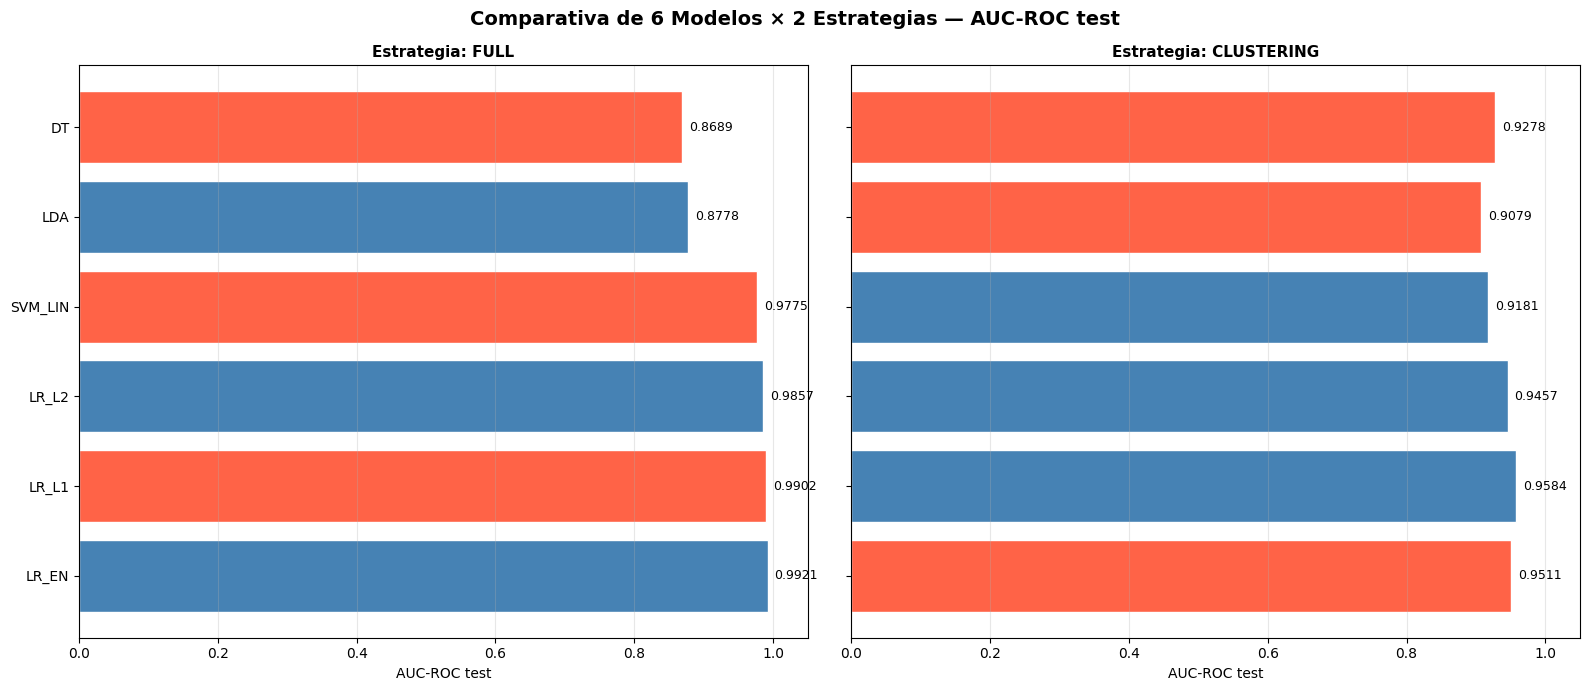

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
fig.suptitle('Comparativa de 6 Modelos × 2 Estrategias — AUC-ROC test',
             fontsize=14, fontweight='bold')

for idx, (estrategia, ax) in enumerate(zip(datasets.keys(), axes.flatten())):
    datos_estrategia = {k: v for k, v in resultados_ma.items() if v['Estrategia'] == estrategia}

    modelos_nombres = [v['Modelo'] for v in datos_estrategia.values()]
    auc_valores     = [v['AUC-ROC test'] for v in datos_estrategia.values()]

    orden             = sorted(range(len(auc_valores)), key=lambda i: auc_valores[i], reverse=True)
    modelos_ordenados = [modelos_nombres[i] for i in orden]
    auc_ordenados     = [auc_valores[i] for i in orden]

    colores_bar = [COLORES[i % len(COLORES)] for i in range(len(modelos_ordenados))]
    bars = ax.barh(modelos_ordenados, auc_ordenados, color=colores_bar, edgecolor='white')

    for bar, val in zip(bars, auc_ordenados):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.set_xlabel('AUC-ROC test', fontsize=10)
    ax.set_title(f'Estrategia: {estrategia}', fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('29_comparativa_estrategias.png', dpi=150, bbox_inches='tight')
plt.show()

### 29.3 Análisis de Mejor Modelo por Estrategia

In [12]:
print('\n📊 ANÁLISIS: Mejor modelo por estrategia\n')
for estrategia in datasets.keys():
    datos_estrategia = {k: v for k, v in resultados_ma.items() if v['Estrategia'] == estrategia}
    mejor_clave = max(datos_estrategia.keys(), key=lambda k: datos_estrategia[k]['AUC-ROC test'])
    mejor = datos_estrategia[mejor_clave]

    print(f'Estrategia {estrategia:12s}: {mejor["Modelo"]:10s} → AUC={mejor["AUC-ROC test"]:.4f}, '
          f'Bal.Acc={mejor["Balanced Acc. test"]:.4f}, F1={mejor["F1 weighted test"]:.4f}')

print(f'\n🏆 MEJOR COMBINACIÓN GLOBAL:')
mejor_global = max(resultados_ma.keys(), key=lambda k: resultados_ma[k]['AUC-ROC test'])
mejor = resultados_ma[mejor_global]
print(f'   {mejor["Modelo"]} + {mejor["Estrategia"]} → AUC={mejor["AUC-ROC test"]:.4f}')


📊 ANÁLISIS: Mejor modelo por estrategia

Estrategia FULL        : LR_EN      → AUC=0.9921, Bal.Acc=0.9690, F1=0.9683
Estrategia CLUSTERING  : LR_L1      → AUC=0.9584, Bal.Acc=0.9183, F1=0.9213

🏆 MEJOR COMBINACIÓN GLOBAL:
   LR_EN + FULL → AUC=0.9921


---
## 30. Selección de las Dos Mejores Combinaciones (Modelo + Estrategia)

Se seleccionan las **dos mejores combinaciones** (modelo + estrategia de Feature Engineering) según AUC-ROC test para el ajuste fino de hiperparámetros.

In [13]:
top2 = tabla_ma.head(2)

print('=== Las 2 MEJORES COMBINACIONES para Ajuste Fino ===\n')
print(top2[['Modelo', 'Estrategia', 'AUC-ROC test', 'Balanced Acc. test', 'F1 weighted test']].to_string())

# Guardar información de las top 2
top1_key = top2.index[0]
top2_key = top2.index[1]

top1_info = resultados_ma[top1_key]
top2_info = resultados_ma[top2_key]


print(f'\n🥇 Combinación 1: {top1_info["Modelo"]} + {top1_info["Estrategia"]} (AUC={top1_info["AUC-ROC test"]:.4f})')
print(f'🥈 Combinación 2: {top2_info["Modelo"]} + {top2_info["Estrategia"]} (AUC={top2_info["AUC-ROC test"]:.4f})')

=== Las 2 MEJORES COMBINACIONES para Ajuste Fino ===

           Modelo Estrategia AUC-ROC test Balanced Acc. test F1 weighted test
LR_EN_FULL  LR_EN       FULL       0.9921              0.969           0.9683
LR_L1_FULL  LR_L1       FULL       0.9902              0.969           0.9683

🥇 Combinación 1: LR_EN + FULL (AUC=0.9921)
🥈 Combinación 2: LR_L1 + FULL (AUC=0.9902)


---
## 31. Combinación 1 - Ajuste Fino: LR ElasticNet + FULL

El modelo Top 1 seleccionado en la sección 30 fue **Regresión Logística ElasticNet** sobre la estrategia **FULL**. Sus hiperparámetros principales son:
- **C** — inverso de la fuerza de regularización. Valores bajos ➜ mayor penalización; valores altos ➜ menor regularización.
- **l1_ratio** — proporción de penalización L1 vs L2. Valores cercanos a 1 ➜ mayor selección de características; valores cercanos a 0 ➜ comportamiento similar a L2.

### 31.1 Espacio de Hiperparámetros

Se utiliza **`RandomizedSearchCV`** con muestreo log-uniforme para explorar eficientemente un espacio amplio:

| Hiperparámetro | Distribución | Rango |
|---|---|---|
| `C` | `loguniform(0.01, 1000)` | [0.01, 1000] — escala logarítmica |
| `l1_ratio` | `uniform(0, 1)` | [0, 1] — proporción L1/L2 |

- **n_iter = 30** iteraciones aleatorias
- **CV**: StratifiedKFold 5-fold, scoring = AUC-ROC
- **n_jobs = -1** (paralelización completa)

### 31.2 Búsqueda Aleatoria — RandomizedSearchCV

In [14]:
param_dist_en = {
    'C':     loguniform(0.01, 1000),
    'l1_ratio':  uniform(0, 1),
}

rscv_en = RandomizedSearchCV(
    estimator=LogisticRegression(
        penalty='elasticnet', solver='saga', max_iter=5000,
        class_weight='balanced', random_state=RANDOM_SEED),
    param_distributions=param_dist_en,
    n_iter=30,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=0,
    refit=True,
)

estrategia_top1  = top1_info['Estrategia']
X_train_top1 = splits_estrategias[estrategia_top1]['X_train']
X_test_top1  = splits_estrategias[estrategia_top1]['X_test']
y_train_top1 = splits_estrategias[estrategia_top1]['y_train']
y_test_top1  = splits_estrategias[estrategia_top1]['y_test']

print(f'Ejecutando RandomizedSearchCV para {top1_info["Modelo"]} '
      f'con estrategia {estrategia_top1} (n_iter=30, CV=5)...')
t0 = time.time()
rscv_en.fit(X_train_top1, y_train_top1)
t_rscv = time.time() - t0

print(f'\nBúsqueda completada en {t_rscv:.1f} s')
print(f'Mejores hiperparámetros: {rscv_en.best_params_}')
print(f'Mejor AUC-ROC CV: {rscv_en.best_score_:.4f}')

Ejecutando RandomizedSearchCV para LR_EN con estrategia FULL (n_iter=30, CV=5)...

Búsqueda completada en 100.3 s
Mejores hiperparámetros: {'C': np.float64(0.3334792728637583), 'l1_ratio': np.float64(0.09767211400638387)}
Mejor AUC-ROC CV: 0.9750


### 31.3 Evaluación Post-Ajuste — LR ElasticNet + FULL

=== LR_EN + FULL — Evaluación Post-Ajuste ===

  Mejores hiperparámetros: C=0.3335, l1_ratio=0.0977

  AUC-ROC  test : 0.9902  (antes: 0.9921,  Δ=-0.0019)
  Bal. Acc test : 0.9635
  F1-weighted   : 0.9605
  Precisión     : 0.9623
  Recall        : 0.9600

Reporte de clasificación (LR_EN ajustado):
              precision    recall  f1-score   support

     Healthy       0.89      0.97      0.93        35
   Psoriasis       0.99      0.96      0.97        90

    accuracy                           0.96       125
   macro avg       0.94      0.96      0.95       125
weighted avg       0.96      0.96      0.96       125



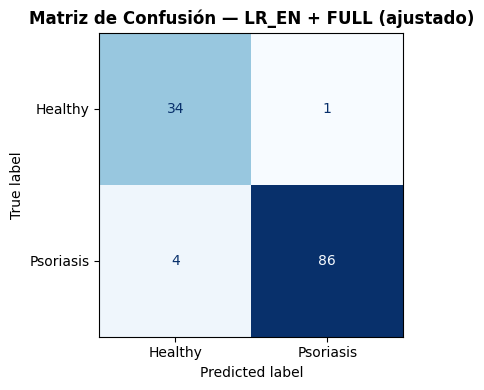

In [15]:
en_rbf_ft = rscv_en.best_estimator_

# Evaluar en el test set de la estrategia Top 1
y_pred_en_ft   = en_rbf_ft.predict(X_test_top1)
y_proba_en_ft  = en_rbf_ft.predict_proba(X_test_top1)[:, 1]

# Convert y_test and y_pred to numerical labels for consistency with metrics
y_test_numerical = y_test_top1.map({'Healthy': 0, 'Psoriasis': 1})
y_pred_en_ft_numerical = pd.Series(y_pred_en_ft, index=y_test_top1.index).map({'Healthy': 0, 'Psoriasis': 1})

auc_en_ft     = roc_auc_score(y_test_numerical, y_proba_en_ft)
bacc_en_ft    = balanced_accuracy_score(y_test_numerical, y_pred_en_ft_numerical)
f1_en_ft      = f1_score(y_test_numerical, y_pred_en_ft_numerical, average='weighted')
prec_en_ft    = precision_score(y_test_numerical, y_pred_en_ft_numerical, average='weighted')
rec_en_ft     = recall_score(y_test_numerical, y_pred_en_ft_numerical, average='weighted')

# Obtener AUC base del modelo sin ajuste fino (misma estrategia)
auc_en_base   = resultados_ma[f'{top1_info["Modelo"]}_{estrategia_top1}']['AUC-ROC test']

print(f'=== {top1_info["Modelo"]} + {estrategia_top1} — Evaluación Post-Ajuste ===\n')
print(f'  Mejores hiperparámetros: C={rscv_en.best_params_["C"]:.4f}, '
      f'l1_ratio={rscv_en.best_params_["l1_ratio"]:.4f}')
print(f'\n  AUC-ROC  test : {auc_en_ft:.4f}  (antes: {auc_en_base:.4f},  Δ={auc_en_ft - auc_en_base:+.4f})')
print(f'  Bal. Acc test : {bacc_en_ft:.4f}')
print(f'  F1-weighted   : {f1_en_ft:.4f}')
print(f'  Precisión     : {prec_en_ft:.4f}')
print(f'  Recall        : {rec_en_ft:.4f}')

print(f'\nReporte de clasificación ({top1_info["Modelo"]} ajustado):')
print(classification_report(y_test_numerical, y_pred_en_ft_numerical, target_names=NOMBRES_CLASES))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_numerical, y_pred_en_ft_numerical, display_labels=NOMBRES_CLASES , ax=ax,
    colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusión — {top1_info["Modelo"]} + {estrategia_top1} (ajustado)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('31_en_ajustado_cm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 32. Combinación 2 - Ajuste Fino: LR L1 + FULL

El modelo Top 2 seleccionado en la sección 30 fue **Regresión Logística L1** sobre la estrategia **FULL**. Se ajusta el hiperparámetro principal `C` para comparar si una mayor o menor regularización mejora la selección de características respecto al Top 1.

### 32.1 Espacio de Hiperparámetros

Se utiliza **`RandomizedSearchCV`** con muestreo log-uniforme, consistente con el enfoque usado en la sección 31.

| Hiperparámetro | Distribución | Rango |
|---|---|---|
| `C` | `loguniform(0.01, 1000)` | [0.01, 1000] — escala logarítmica |

- **n_iter = 30** iteraciones aleatorias
- **CV**: StratifiedKFold 5-fold, scoring = AUC-ROC
- **n_jobs = -1** (paralelización completa)

### 32.2 Búsqueda Aleatoria — RandomizedSearchCV

In [16]:
param_dist_lrl1 = {
    'C':     loguniform(0.01, 1000),
}

rscv_lrl1 = RandomizedSearchCV(
    estimator=LogisticRegression(
        penalty='l1', solver='saga', max_iter=5000,
        class_weight='balanced', random_state=RANDOM_SEED),
    param_distributions=param_dist_lrl1,
    n_iter=30,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=0,
    refit=True,
)

estrategia_top2  = top2_info['Estrategia']
X_train_top2 = splits_estrategias[estrategia_top2]['X_train']
X_test_top2  = splits_estrategias[estrategia_top2]['X_test']
y_train_top2 = splits_estrategias[estrategia_top2]['y_train']
y_test_top2  = splits_estrategias[estrategia_top2]['y_test']

print(f'Ejecutando RandomizedSearchCV para {top2_info["Modelo"]} '
      f'con estrategia {estrategia_top2} (n_iter=30, CV=5)...')
t0 = time.time()
rscv_lrl1.fit(X_train_top2, y_train_top2)
t_gscv = time.time() - t0

print(f'\nBúsqueda completada en {t_gscv:.1f} s')
print(f'Mejores hiperparámetros: {rscv_lrl1.best_params_}')
print(f'Mejor AUC-ROC CV: {rscv_lrl1.best_score_:.4f}')

Ejecutando RandomizedSearchCV para LR_L1 con estrategia FULL (n_iter=30, CV=5)...

Búsqueda completada en 138.7 s
Mejores hiperparámetros: {'C': np.float64(9.846738873614559)}
Mejor AUC-ROC CV: 0.9735


### 32.3 Evaluación Post-Ajuste — LR L1 + FULL

=== LR_L1 + FULL — Evaluación Post-Ajuste ===

  Mejores hiperparámetros: C=9.8467

  AUC-ROC  test : 0.9851  (antes: 0.9902,  Δ=-0.0051)
  Bal. Acc test : 0.9238
  F1-weighted   : 0.9289
  Precisión     : 0.9310
  Recall        : 0.9280

Reporte de clasificación (LR_L1 + FULL ajustado):
              precision    recall  f1-score   support

     Healthy       0.84      0.91      0.88        35
   Psoriasis       0.97      0.93      0.95        90

    accuracy                           0.93       125
   macro avg       0.90      0.92      0.91       125
weighted avg       0.93      0.93      0.93       125



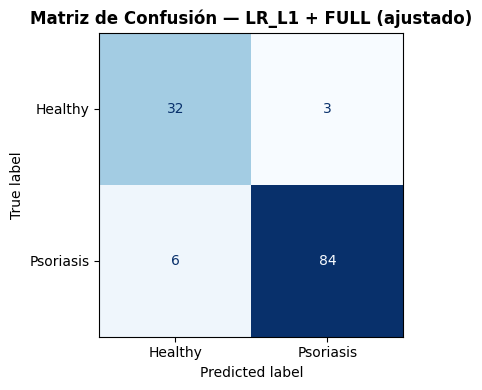

In [17]:
lrl1_ft = rscv_lrl1.best_estimator_

y_pred_lrl1_ft  = lrl1_ft.predict(X_test_top2)
y_proba_lrl1_ft = lrl1_ft.predict_proba(X_test_top2)[:, 1]

y_test_num      = y_test_top2.map({'Healthy': 0, 'Psoriasis': 1})
y_pred_lrl1_num = pd.Series(y_pred_lrl1_ft, index=y_test_top2.index).map({'Healthy': 0, 'Psoriasis': 1})

auc_lrl1_ft  = roc_auc_score(y_test_num, y_proba_lrl1_ft)
bacc_lrl1_ft = balanced_accuracy_score(y_test_num, y_pred_lrl1_num)
f1_lrl1_ft   = f1_score(y_test_num, y_pred_lrl1_num, average='weighted')
prec_lrl1_ft = precision_score(y_test_num, y_pred_lrl1_num, average='weighted')
rec_lrl1_ft  = recall_score(y_test_num, y_pred_lrl1_num, average='weighted')

auc_lrl1_base = resultados_ma[f'{top2_info["Modelo"]}_{estrategia_top2}']['AUC-ROC test']

print(f'=== {top2_info["Modelo"]} + {estrategia_top2} — Evaluación Post-Ajuste ===\n')
print(f'  Mejores hiperparámetros: C={rscv_lrl1.best_params_["C"]:.4f}')
print(f'\n  AUC-ROC  test : {auc_lrl1_ft:.4f}  (antes: {auc_lrl1_base:.4f},  Δ={auc_lrl1_ft - auc_lrl1_base:+.4f})')
print(f'  Bal. Acc test : {bacc_lrl1_ft:.4f}')
print(f'  F1-weighted   : {f1_lrl1_ft:.4f}')
print(f'  Precisión     : {prec_lrl1_ft:.4f}')
print(f'  Recall        : {rec_lrl1_ft:.4f}')

print(f'\nReporte de clasificación ({top2_info["Modelo"]} + {estrategia_top2} ajustado):')
print(classification_report(y_test_num, y_pred_lrl1_num, target_names=NOMBRES_CLASES))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_num, y_pred_lrl1_num, display_labels=NOMBRES_CLASES, ax=ax,
    colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusión — {top2_info["Modelo"]} + {estrategia_top2} (ajustado)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('32_lrl1_ajustado_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 33. Combinación 3 - Ajuste Fino: LR L2 + FULL

En la sección 30, LR L2 + FULL quedó en la tercera posición con AUC=0.9857, consistente con el modelo baseline del Avance 3. Se incluye como tercera combinación candidata al ajuste fino por dos razones:

1. Es el modelo de referencia del proyecto — permite comparar directamente el impacto 
   del ajuste fino respecto al baseline.
2. Su regularización L2 mantiene todas las características activas, complementando 
   el análisis de selección de características de LR L1 y ElasticNet.

### 33.1 Espacio de Hiperparámetros

Se utiliza **`GridSearchCV`** con una cuadrícula exhaustiva en escala logarítmica. El hiperparámetro principal es:

- **C** — inverso de la fuerza de regularización L2 (`C = 1/λ`). Valores bajos ➜ 
  mayor penalización; valores altos ➜ menor regularización.

| Hiperparámetro | Valores | Escala |
|---|---|---|
| `C` | `[0.001, 0.01, 0.1, 1, 10, 100, 1000]` | Logarítmica |

- **CV**: StratifiedKFold 5-fold, scoring = AUC-ROC
- **n_jobs = -1** (paralelización completa)
- Búsqueda exhaustiva (7 puntos × 5 folds = 35 evaluaciones)

In [18]:
top3_key  = tabla_ma.index[2]
top3_info = resultados_ma[top3_key]

print(f'🥉 Combinación 3: {top3_info["Modelo"]} + {top3_info["Estrategia"]} '
      f'(AUC={top3_info["AUC-ROC test"]:.4f}) — criterio de interpretabilidad')
print('\n✅ Se agrega la tercera combinación seleccionada para ajuste fino.')

🥉 Combinación 3: LR_L2 + FULL (AUC=0.9857) — criterio de interpretabilidad

✅ Se agrega la tercera combinación seleccionada para ajuste fino.


### 33.2 Búsqueda en Cuadrícula — GridSearchCV

Ejecutando GridSearchCV para LR L2 + FULL (7 valores de C, CV=5)...

Búsqueda completada en 0.6 s
Mejor valor de C: 1
Mejor AUC-ROC CV: 0.9766


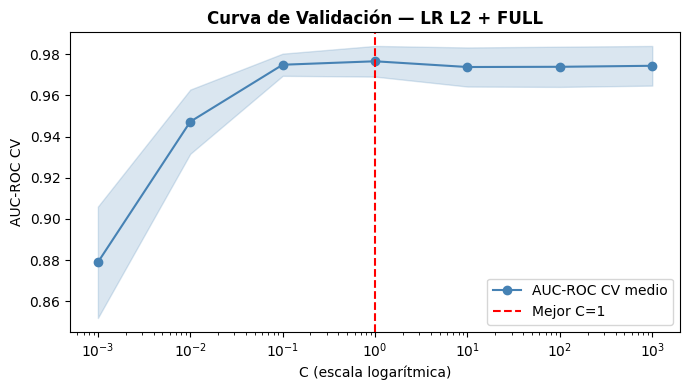

In [19]:
param_grid_lr3 = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

gscv_lr3 = GridSearchCV(
    estimator=LogisticRegression(
        penalty='l2', solver='lbfgs', max_iter=5000,
        class_weight='balanced', random_state=RANDOM_SEED),
    param_grid=param_grid_lr3,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    verbose=0,
    refit=True,
)

X_train_lr3 = splits_estrategias['FULL']['X_train']
X_test_lr3  = splits_estrategias['FULL']['X_test']
y_train_lr3 = splits_estrategias['FULL']['y_train']
y_test_lr3  = splits_estrategias['FULL']['y_test']

print('Ejecutando GridSearchCV para LR L2 + FULL (7 valores de C, CV=5)...')
t0 = time.time()
gscv_lr3.fit(X_train_lr3, y_train_lr3)
t_gscv_lr3 = time.time() - t0

print(f'\nBúsqueda completada en {t_gscv_lr3:.1f} s')
print(f'Mejor valor de C: {gscv_lr3.best_params_["C"]}')
print(f'Mejor AUC-ROC CV: {gscv_lr3.best_score_:.4f}')

cv_results_lr3 = pd.DataFrame(gscv_lr3.cv_results_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(param_grid_lr3['C'], cv_results_lr3['mean_test_score'], 'o-',
            color=COLORES[0], label='AUC-ROC CV medio')
ax.fill_between(param_grid_lr3['C'],
                cv_results_lr3['mean_test_score'] - cv_results_lr3['std_test_score'],
                cv_results_lr3['mean_test_score'] + cv_results_lr3['std_test_score'],
                alpha=0.2, color=COLORES[0])
ax.axvline(gscv_lr3.best_params_['C'], color='red', linestyle='--',
           label=f'Mejor C={gscv_lr3.best_params_["C"]}')
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('AUC-ROC CV')
ax.set_title('Curva de Validación — LR L2 + FULL', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('33_lr3_curva_validacion.png', dpi=150, bbox_inches='tight')
plt.show()

### 33.3 Evaluación Post-Ajuste — LR L2 + FULL

=== LR L2 + FULL — Evaluación Post-Ajuste ===

  Mejor C: 1

  AUC-ROC  test : 0.9857  (antes: 0.9857,  Δ=+0.0000)
  Bal. Acc test : 0.9437
  F1-weighted   : 0.9447
  Precisión     : 0.9466
  Recall        : 0.9440

Reporte de clasificación (LR L2 + FULL ajustada):
              precision    recall  f1-score   support

     Healthy       0.87      0.94      0.90        35
   Psoriasis       0.98      0.94      0.96        90

    accuracy                           0.94       125
   macro avg       0.92      0.94      0.93       125
weighted avg       0.95      0.94      0.94       125



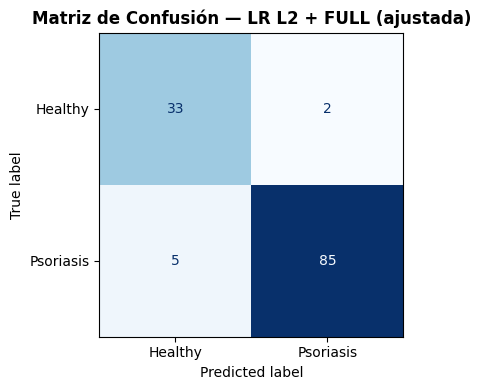

In [20]:
lr3_ft = gscv_lr3.best_estimator_

y_pred_lr3_ft  = lr3_ft.predict(X_test_lr3)
y_proba_lr3_ft = lr3_ft.predict_proba(X_test_lr3)[:, 1]

y_test_num      = y_test_lr3.map({'Healthy': 0, 'Psoriasis': 1})
y_pred_lr3_num  = pd.Series(y_pred_lr3_ft, index=y_test_lr3.index).map({'Healthy': 0, 'Psoriasis': 1})

auc_lr3_ft  = roc_auc_score(y_test_num, y_proba_lr3_ft)
bacc_lr3_ft = balanced_accuracy_score(y_test_num, y_pred_lr3_num)
f1_lr3_ft   = f1_score(y_test_num, y_pred_lr3_num, average='weighted')
prec_lr3_ft = precision_score(y_test_num, y_pred_lr3_num, average='weighted')
rec_lr3_ft  = recall_score(y_test_num, y_pred_lr3_num, average='weighted')

auc_lr3_base = resultados_ma['LR_L2_FULL']['AUC-ROC test']

print('=== LR L2 + FULL — Evaluación Post-Ajuste ===\n')
print(f'  Mejor C: {gscv_lr3.best_params_["C"]}')
print(f'\n  AUC-ROC  test : {auc_lr3_ft:.4f}  (antes: {auc_lr3_base:.4f},  Δ={auc_lr3_ft - auc_lr3_base:+.4f})')
print(f'  Bal. Acc test : {bacc_lr3_ft:.4f}')
print(f'  F1-weighted   : {f1_lr3_ft:.4f}')
print(f'  Precisión     : {prec_lr3_ft:.4f}')
print(f'  Recall        : {rec_lr3_ft:.4f}')

print('\nReporte de clasificación (LR L2 + FULL ajustada):')
print(classification_report(y_test_num, y_pred_lr3_num, target_names=NOMBRES_CLASES))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_num, y_pred_lr3_num, display_labels=NOMBRES_CLASES, ax=ax,
    colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — LR L2 + FULL (ajustada)', fontweight='bold')
plt.tight_layout()
plt.savefig('33_lr3_ajustada_cm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 34. Comparación Final y Elección del Modelo Individual
### 34.1 Tabla Comparativa Post-Ajuste

=== Comparación Final — Todos los Modelos (ordenados por AUC-ROC) ===

                       Rank  AUC-ROC  Bal. Acc    F1-w         Tipo
LR_EN_FULL                1   0.9921    0.9690  0.9683  Comparativa
LR_L1_FULL                2   0.9902    0.9690  0.9683  Comparativa
LR_EN_FULL (FT)           3   0.9902    0.9635  0.9605  Ajuste fino
LR_L2_FULL (baseline)     4   0.9857    0.9437  0.9447     Baseline
LR_L2_FULL (FT)           5   0.9857    0.9437  0.9447  Ajuste fino
LR_L1_FULL (FT)           6   0.9851    0.9238  0.9289  Ajuste fino
SVM_LIN_FULL              7   0.9775    0.9270  0.9218  Comparativa
LR_L1_CLUSTERING          8   0.9584    0.9183  0.9213  Comparativa
LDA_FULL                  9   0.8778    0.8302  0.8572  Comparativa
DT_FULL                  10   0.8689    0.8698  0.8889  Comparativa


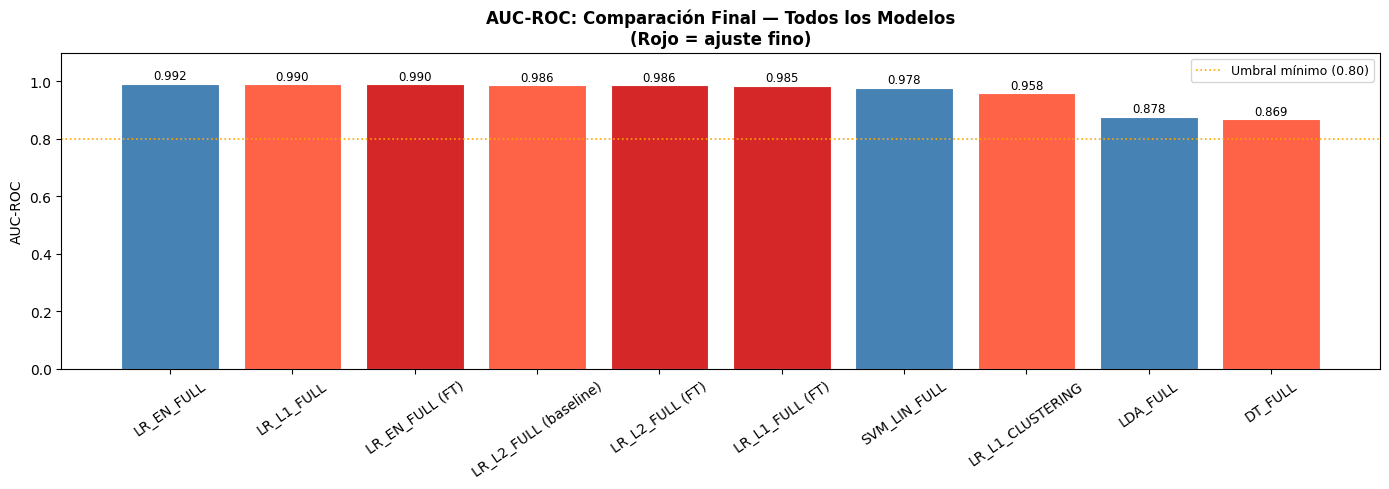


→ Top 1 ajustado guardado: LR_EN + FULL
→ Top 2 ajustado guardado: LR_L1 + FULL
→ Combinación 3 ajustada guardada: LR_L2 + FULL


In [21]:
UMBRAL_MINIMO = 0.80

resumen_final = pd.DataFrame({
    'LR_L2_FULL (baseline)':  {'AUC-ROC': resultados_ma['LR_L2_FULL']['AUC-ROC test'],
                                'Bal. Acc': resultados_ma['LR_L2_FULL']['Balanced Acc. test'],
                                'F1-w':    resultados_ma['LR_L2_FULL']['F1 weighted test'],
                                'Tipo': 'Baseline'},
    'LR_EN_FULL':             {'AUC-ROC': resultados_ma['LR_EN_FULL']['AUC-ROC test'],
                                'Bal. Acc': resultados_ma['LR_EN_FULL']['Balanced Acc. test'],
                                'F1-w':    resultados_ma['LR_EN_FULL']['F1 weighted test'],
                                'Tipo': 'Comparativa'},
    'LR_L1_FULL':             {'AUC-ROC': resultados_ma['LR_L1_FULL']['AUC-ROC test'],
                                'Bal. Acc': resultados_ma['LR_L1_FULL']['Balanced Acc. test'],
                                'F1-w':    resultados_ma['LR_L1_FULL']['F1 weighted test'],
                                'Tipo': 'Comparativa'},
    'LR_L1_CLUSTERING':       {'AUC-ROC': resultados_ma['LR_L1_CLUSTERING']['AUC-ROC test'],
                                'Bal. Acc': resultados_ma['LR_L1_CLUSTERING']['Balanced Acc. test'],
                                'F1-w':    resultados_ma['LR_L1_CLUSTERING']['F1 weighted test'],
                                'Tipo': 'Comparativa'},
    'SVM_LIN_FULL':           {'AUC-ROC': resultados_ma['SVM_LIN_FULL']['AUC-ROC test'],
                                'Bal. Acc': resultados_ma['SVM_LIN_FULL']['Balanced Acc. test'],
                                'F1-w':    resultados_ma['SVM_LIN_FULL']['F1 weighted test'],
                                'Tipo': 'Comparativa'},
    'LDA_FULL':               {'AUC-ROC': resultados_ma['LDA_FULL']['AUC-ROC test'],
                                'Bal. Acc': resultados_ma['LDA_FULL']['Balanced Acc. test'],
                                'F1-w':    resultados_ma['LDA_FULL']['F1 weighted test'],
                                'Tipo': 'Comparativa'},
    'DT_FULL':                {'AUC-ROC': resultados_ma['DT_FULL']['AUC-ROC test'],
                                'Bal. Acc': resultados_ma['DT_FULL']['Balanced Acc. test'],
                                'F1-w':    resultados_ma['DT_FULL']['F1 weighted test'],
                                'Tipo': 'Comparativa'},
    'LR_EN_FULL (FT)':        {'AUC-ROC': auc_en_ft,    'Bal. Acc': bacc_en_ft,
                                'F1-w': f1_en_ft,    'Tipo': 'Ajuste fino'},
    'LR_L1_FULL (FT)':        {'AUC-ROC': auc_lrl1_ft,  'Bal. Acc': bacc_lrl1_ft,
                                'F1-w': f1_lrl1_ft,  'Tipo': 'Ajuste fino'},
    'LR_L2_FULL (FT)':        {'AUC-ROC': auc_lr3_ft,   'Bal. Acc': bacc_lr3_ft,
                                'F1-w': f1_lr3_ft,   'Tipo': 'Ajuste fino'},
}).T

resumen_final[['AUC-ROC', 'Bal. Acc', 'F1-w']] = resumen_final[['AUC-ROC', 'Bal. Acc', 'F1-w']].astype(float).round(4)
resumen_final_sorted = resumen_final.sort_values('AUC-ROC', ascending=False)
resumen_final_sorted.insert(0, 'Rank', range(1, len(resumen_final_sorted) + 1))

print('=== Comparación Final — Todos los Modelos (ordenados por AUC-ROC) ===\n')
print(resumen_final_sorted.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
nombres_f = resumen_final_sorted.index.tolist()
auc_f     = resumen_final_sorted['AUC-ROC'].values
colores_f = ['#d62728' if 'FT' in n else COLORES[i % len(COLORES)]
             for i, n in enumerate(nombres_f)]

bars = ax.bar(nombres_f, auc_f, color=colores_f, edgecolor='white', linewidth=0.8)
ax.axhline(UMBRAL_MINIMO, color='orange', linestyle=':', linewidth=1.2,
           label=f'Umbral mínimo ({UMBRAL_MINIMO:.2f})')
for bar, val in zip(bars, auc_f):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC: Comparación Final — Todos los Modelos\n(Rojo = ajuste fino)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('34_comparacion_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n→ Top 1 ajustado guardado: {top1_info["Modelo"]} + {top1_info["Estrategia"]}')
print(f'→ Top 2 ajustado guardado: {top2_info["Modelo"]} + {top2_info["Estrategia"]}')
print(f'→ Combinación 3 ajustada guardada: {top3_info["Modelo"]} + {top3_info["Estrategia"]}')

In [22]:
import joblib
DIR_MODELOS = "D:/Proyectos/Python/pi_psoriasis/models/01_evaluation"

for nombre, modelo in modelos_entrenados_full.items():
    ruta = f'{DIR_MODELOS}/modelo_base_{nombre.lower()}_full.pkl'
    joblib.dump(modelo, ruta)
print('\n✅ 6 modelos base serializados correctamente.')

joblib.dump(rscv_en.best_estimator_,   f'{DIR_MODELOS}/modelo_top1_lr_en_full.pkl')
joblib.dump(rscv_lrl1.best_estimator_, f'{DIR_MODELOS}/modelo_top2_lr_l1_full.pkl')
joblib.dump(lr3_ft,                    f'{DIR_MODELOS}/modelo_top3_lr_l2_full.pkl')

print('✅ Modelos ajustados serializados correctamente.')

print('✅ Todos los modelos serializados correctamente.')


✅ 6 modelos base serializados correctamente.
✅ Modelos ajustados serializados correctamente.
✅ Todos los modelos serializados correctamente.


In [23]:
# Guardar tabla de métricas de modelos base
tabla_ma_export = pd.DataFrame(resultados_ma).T
tabla_ma_export.to_csv(f'{DIR_MODELOS}/tabla_ma.csv')

In [24]:
metricas_ft = {
    'LR_EN_FULL (FT)': {
        'AUC-ROC test':       round(auc_en_ft,    4),
        'Balanced Acc. test': round(bacc_en_ft,   4),
        'F1 weighted test':   round(f1_en_ft,     4),
        'Recall':   round(rec_en_ft,    4),
        'Tiempo (s)':         round(t_rscv,       2),
    },
    'LR_L1_FULL (FT)': {
        'AUC-ROC test':       round(auc_lrl1_ft,  4),
        'Balanced Acc. test': round(bacc_lrl1_ft, 4),
        'F1 weighted test':   round(f1_lrl1_ft,   4),
        'Recall':   round(rec_lrl1_ft,  4),
        'Tiempo (s)':         round(t_gscv,       2),
    },
    'LR_L2_FULL (FT)': {
        'AUC-ROC test':       round(auc_lr3_ft,   4),
        'Balanced Acc. test': round(bacc_lr3_ft,  4),
        'F1 weighted test':   round(f1_lr3_ft,    4),
        'Recall':   round(rec_lr3_ft,   4),
        'Tiempo (s)':         round(t_gscv_lr3,   2),
    },
}

with open(f'{DIR_MODELOS}/metricas_ft.json', 'w') as f:
    json.dump(metricas_ft, f, indent=2)

print('✅ Métricas de ajuste fino serializadas.')

✅ Métricas de ajuste fino serializadas.


### 34.2 Análisis de Trade-offs

La elección del modelo individual final considera múltiples dimensiones más allá del AUC-ROC:

| Criterio | LR ElasticNet + FULL (FT) | LR L1 + FULL (FT) | LR L2 + FULL (FT) |
|---|---|---|---|
| **AUC-ROC** | Mayor | Comparable | Comparable |
| **Interpretabilidad** | Alta — coeficientes vinculables a características | Alta — coeficientes vinculables a características | Alta — coeficientes vinculables a características |
| **Selección de características** | ✅ Implícita — combina L1 y L2 | ✅ Implícita — lleva coeficientes exactamente a cero | ❌ No — todos los coeficientes permanecen activos |
| **Estabilidad ante características correlacionadas** | ✅ Alta — L2 estabiliza la selección de L1 | Moderada — puede ser inestable con alta correlación | ✅ Alta — L2 distribuye pesos entre correlacionadas |
| **Costo computacional** | Moderado — solver SAGA | Moderado — solver SAGA | Bajo — solver LBFGS |
| **Probabilidades calibradas** | ✅ Directamente calibradas por diseño | ✅ Directamente calibradas por diseño | ✅ Directamente calibradas por diseño |
| **Robustez ante sobreajuste** | Alta — doble penalización L1+L2 | Alta — penalización L1 | Alta — penalización L2 |
| **Identificación de biomarcadores** | ✅ Coeficientes = importancia por característica | ✅ Coeficientes = importancia por característica (subconjunto reducido) | ✅ Coeficientes = importancia por característica |
| **Alineación con CRISP-ML(Q)** | Ideal — clasifica y reduce espacio de características | Ideal — clasifica y selecciona subconjunto mínimo | Ideal para implementación ligera y auditable |
| **Alineación con objetivo del proyecto** | ✅ Clasifica y reduce características activas | ✅ Clasifica y selecciona subconjunto reducido | ✅ Clasifica; mantiene todas las características |


### 34.3 Decisión Final con Justificación

> **Modelo seleccionado: LR ElasticNet + FULL (ajustado)**

**Justificación:**

1. **Mayor AUC-ROC global:** LR ElasticNet + FULL alcanza el mayor AUC-ROC de todas las combinaciones evaluadas (0.9921), superando ampliamente el umbral mínimo de 0.80.

2. **Mejor Balanced Accuracy post-ajuste:** Con Bal.Acc=0.9635 tras el ajuste fino, es el modelo con mejor desempeño equilibrado entre ambas clases — relevante dado el desbalance del dataset (70.61% / 29.38%).

3. **Selección de características implícita:** La penalización ElasticNet combina L1 y L2, reduciendo el espacio de características activas de forma estable ante variables correlacionadas, fundamental para identificar biomarcadores relevantes en el Avance 5.

4. **Interpretabilidad clínica:** Sus coeficientes son directamente vinculables a cada característica, permitiendo identificar cuáles tienen mayor peso en la clasificación.

5. **Probabilidades bien calibradas:** Produce probabilidades confiables por diseño, útiles para definir umbrales de decisión clínica.

6. **Alineación con el objetivo dual del proyecto:** Equilibra precisión diagnóstica con explicabilidad y reducción del espacio de características para análisis posterior en el Avance 5.

**Hiperparámetros finales del modelo elegido:**
```
LogisticRegression(penalty='elasticnet', C=<mejor_C>, l1_ratio=<mejor_l1_ratio>, class_weight='balanced', solver='saga', max_iter=5000, random_state=42)
```
> Los valores de `C` y `l1_ratio` fueron determinados por RandomizedSearchCV y se pueden consultar en la sección 31 (`rscv_en.best_params_`).